1. Data Scoping and Preparation

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

# Chargement du jeu de données
df = pd.read_csv('Sample - Superstore.csv', encoding='ISO-8859-1')

# Traitement des doublons et valeurs manquantes
print(f"Doublons identifiés et supprimés : {df.duplicated().sum()}")
df = df.drop_duplicates()

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)
    
# Réinitialisation de l'index pour éviter les erreurs d'alignement
df = df.reset_index(drop=True)

Doublons identifiés et supprimés : 0


Correction des types de données & Feature Engineering

In [10]:
# Conversion en datetime
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Feature Engineering
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

2. Deep-Dive Exploratory Analysis (Matplotlib)

In [11]:
# Préparation des données chronologiques
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 5))
    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, 
                 marker='o', color='#1f77b4', linewidth=2, markersize=5)
        plt.title('Monthly Sales Trend - All Categories', fontsize=14, fontweight='bold', pad=15)
    else:
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'], 
                 marker='o', color='#ff7f0e', linewidth=2, markersize=5)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=14, fontweight='bold', pad=15)

    plt.xlabel('Order Date', fontsize=11)
    plt.ylabel('Sales ($)', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

categories = ['All'] + list(df['Category'].unique())
interact(plot_monthly_sales, category=Dropdown(options=categories, value='All', description='Category:'));

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

Diagnostic : Les ventes affichent une forte saisonnalité historique, caractérisée par une accélération agressive au quatrième trimestre (Q4), portée par le segment Technology et les fournitures de bureau (effet Black Friday / fêtes de fin d'année).

Performance des ventes géographiques

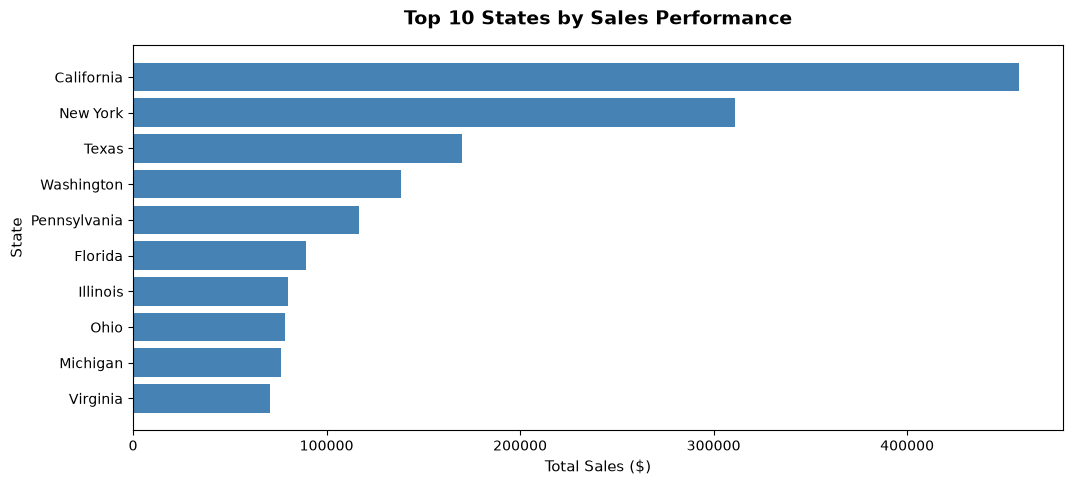

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

In [12]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(5, top_n * 0.4)))
    top_states = state_sales.tail(top_n)
    
    bars = plt.barh(range(len(top_states)), top_states.values, color='#4682B4', edgecolor='none')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=11)
    plt.ylabel('State', fontsize=11)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=14, fontweight='bold', pad=15)

    # Ajout du Jittering visuel de texte (positionnement des étiquettes)
    max_val = max(top_states.values())
    for i, value in enumerate(top_states.values):
        plt.text(value + (max_val * 0.01), i, f'${value:,.0f}', va='center', fontsize=9)

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

interact(plot_top_states, top_n=IntSlider(min=5, max=25, value=10, description='Top N States:'));

3. Communicating Insights (Seaborn)
 Top 10 des produits les plus rentables

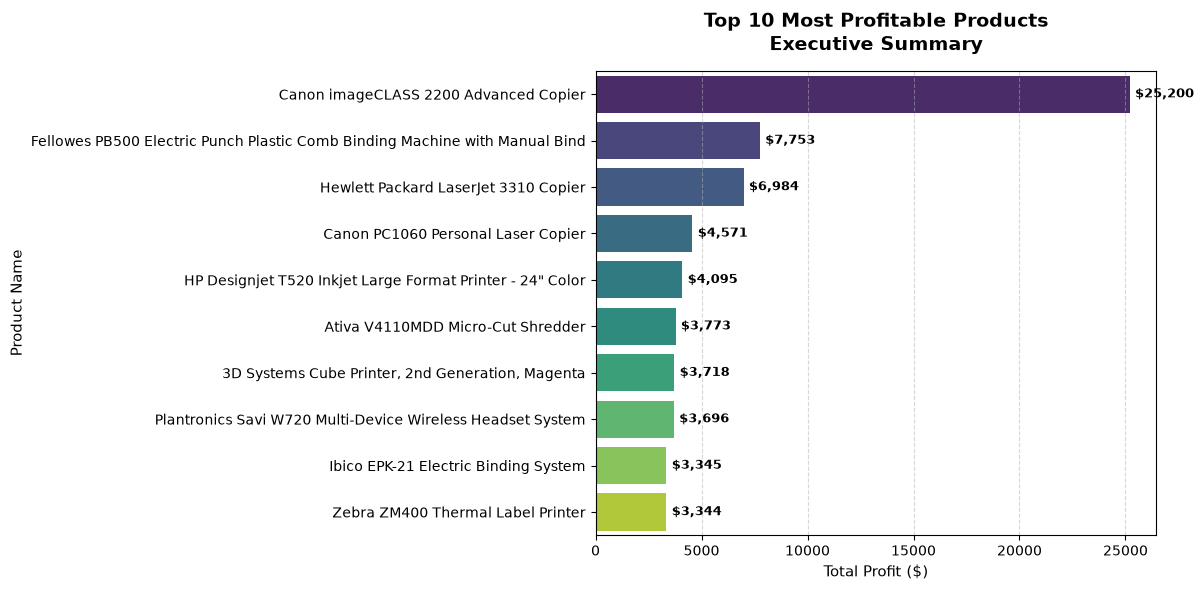

In [13]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis', orient='h')
plt.title('Top 10 Most Profitable Products\nExecutive Summary', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Profit ($)', fontsize=11)
plt.ylabel('Product Name', fontsize=11)

for i, profit in enumerate(product_profit.values):
    ax.text(profit + (max(product_profit.values) * 0.01), i, f'${profit:,.0f}', va='center', fontweight='bold', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

 Corrélation Remise vs Profit (Discount vs Profit)

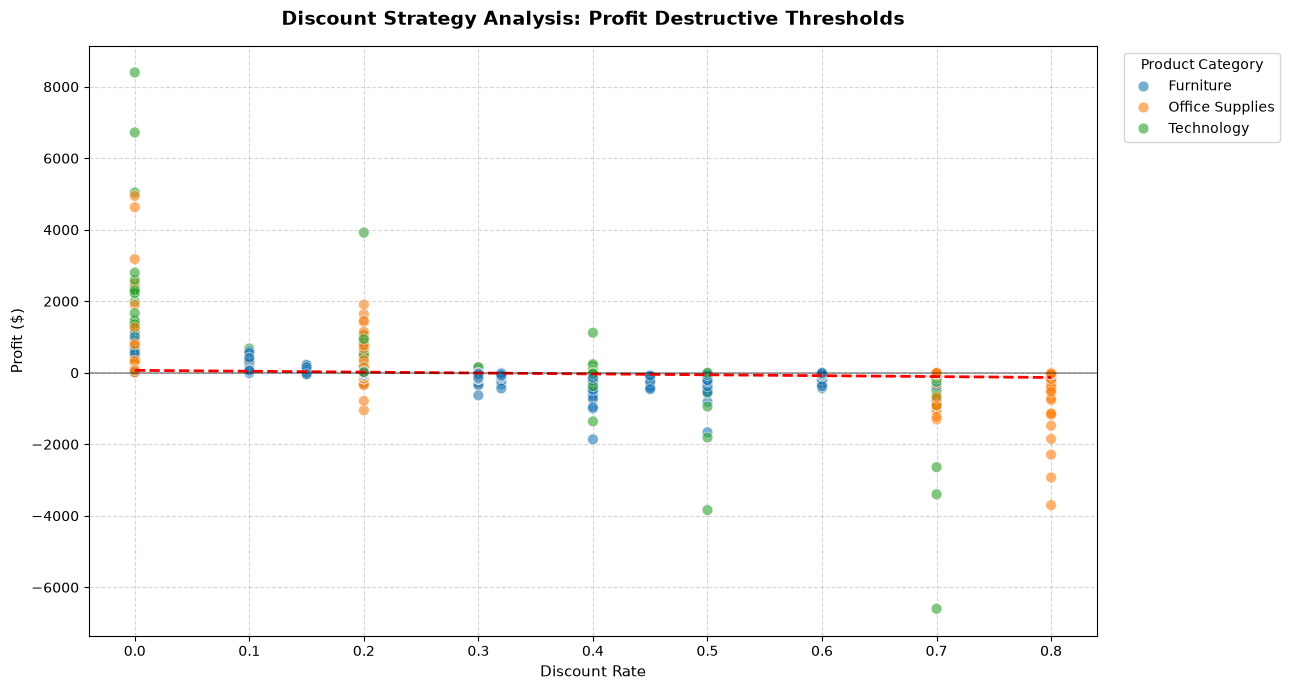

In [14]:
plt.figure(figsize=(13, 7))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=60)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Discount Strategy Analysis: Profit Destructive Thresholds', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Rate', fontsize=11)
plt.ylabel('Profit ($)', fontsize=11)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Product Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Executive Summary : Synthèse pour la Direction

In [15]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100

print("=== EXECUTIVE SUMMARY - KEY FINDINGS ===")
print(f"PERFORMANCE GLOBALE : CA Total de ${total_sales:,.0f} | Profit global de ${total_profit:,.0f} (Marge : {profit_margin:.2f}%)")
print(f"CONCENTRATION GÉOGRAPHIQUE : Top 5 des États représentent {(state_sales.tail(5).sum()/total_sales)*100:.1f}% du chiffre d'affaires national.")
print(f"SEUIL DE RISQUE DES REMISES : {high_discount_loss_rate:.1f}% des transactions avec une remise supérieure à 20% se font à PERTE.")

=== EXECUTIVE SUMMARY - KEY FINDINGS ===
PERFORMANCE GLOBALE : CA Total de $2,297,201 | Profit global de $286,397 (Marge : 12.47%)
CONCENTRATION GÉOGRAPHIQUE : Top 5 des États représentent 52.0% du chiffre d'affaires national.
SEUIL DE RISQUE DES REMISES : 96.8% des transactions avec une remise supérieure à 20% se font à PERTE.
